# Análisis de Ventas Online

## Descripción

Análisis exploratorio de datos de ventas online utilizando Python y las librerías Pandas, NumPy, Matplotlib y Seaborn.
El objetivo es identificar patrones de ventas, productos de mayor rendimiento, comportamiento de los clientes y mercados con mayor generación de ingresos.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga de datos

In [2]:
ruta = r"C:\Users\Leyer\workspace_jupyter\proyectos\proyecto_analisis_ventas\data\Online Retail.xlsx"
df = pd.read_csv(ruta)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Exploración inicial de los datos

In [3]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [8]:
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [10]:
df[df["Quantity"] < 0].shape

(10624, 8)

In [11]:
df[df["Quantity"] < 0]["InvoiceNo"].head(20)

141     C536379
154     C536383
235     C536391
236     C536391
237     C536391
238     C536391
239     C536391
240     C536391
241     C536391
939     C536506
1441    C536543
1442    C536543
1973    C536548
1974    C536548
1975    C536548
1976    C536548
1977    C536548
1978    C536548
1979    C536548
1980    C536548
Name: InvoiceNo, dtype: str

In [14]:
df[df["Quantity"] < 0]["InvoiceNo"].str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [15]:
df[(df["Quantity"] < 0) & (~df["InvoiceNo"].str.startswith("C"))].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [18]:
df[(df["Quantity"] < 0) & (~df["InvoiceNo"].str.startswith("C"))]["Description"].value_counts().head(20)

Description
check                         120
damages                        45
damaged                        42
?                              41
sold as set on dotcom          20
Damaged                        14
thrown away                     9
Unsaleable, destroyed.          9
??                              7
damages?                        5
wet damaged                     5
ebay                            5
smashed                         4
missing                         3
CHECK                           3
wet pallet                      3
Dotcom sales                    2
reverse 21/5/10 adjustment      2
counted                         2
crushed                         2
Name: count, dtype: int64

In [20]:
df["Quantity"].lt(0).sum()

np.int64(10624)

In [21]:
df["InvoiceNo"].str.startswith("C").sum()

np.int64(9288)

In [22]:
((df["Quantity"] < 0) & (df["UnitPrice"] == 0)).sum()

np.int64(1336)

In [23]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [24]:
df[df["UnitPrice"] < 0].shape

(2, 8)

## 4. Limpieza de datos

Se realizó un proceso de limpieza para identificar y tratar valores negativos, valores nulos, registros duplicados y formatos incorrectos en las variables.

In [25]:
df_clean = df.copy()

In [26]:
df_clean = df_clean[df_clean["UnitPrice"] >= 0]

In [27]:
df_clean.shape

(541907, 8)

In [28]:
df_clean.duplicated().sum()

np.int64(5268)

In [23]:
df_clean[df_clean.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [29]:
df_clean = df_clean.drop_duplicates()

In [30]:
df_clean.shape

(536639, 8)

In [31]:
df_clean.duplicated().sum()

np.int64(0)

In [32]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135035
Country             0
dtype: int64

In [31]:
df_clean[df_clean["Description"].isnull()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [32]:
(df_clean["Description"].isnull() & (df_clean["UnitPrice"] == 0)).sum()

np.int64(1454)

In [33]:
df_clean = df_clean[df_clean["Description"].notna()]

In [34]:
df_clean.shape

(535185, 8)

In [35]:
(df_clean["Quantity"] < 0).sum()

np.int64(9725)

In [36]:
df_clean["InvoiceNo"].str.startswith("C").sum()

np.int64(9251)

### Eliminación de cantidades no válidas

Se eliminaron los registros con cantidades menores o iguales a cero, ya que el análisis se centra en las ventas realizadas.

In [37]:
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean.shape

(525460, 8)

In [38]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [39]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 525460 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    525460 non-null  str           
 1   StockCode    525460 non-null  str           
 2   Description  525460 non-null  str           
 3   Quantity     525460 non-null  int64         
 4   InvoiceDate  525460 non-null  datetime64[us]
 5   UnitPrice    525460 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      525460 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 62.0 MB


## 5. Creación de variables

Se crearon nuevas variables derivadas de los datos originales para facilitar el análisis de las ventas.

In [40]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [41]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 6. Métricas generales de ventas

Se calcularon métricas generales para obtener una visión inicial del comportamiento de las ventas, incluyendo ingresos totales, ingreso promedio por registro, número de facturas y ticket promedio.

In [80]:
ingresos_totales = df_clean["Revenue"].sum()
ingreso_promedio = df_clean["Revenue"].mean()
numero_facturas = df_clean["InvoiceNo"].nunique()

print(f"Ingresos totales: {ingresos_totales:.2f}")
print(f"Ingreso promedio por registro: {ingreso_promedio:,.2f}")
print(f"Número de facturas: {numero_facturas:}")

Ingresos totales: 10642110.80
Ingreso promedio por registro: 20.25
Número de facturas: 20134


In [81]:
ticket_promedio = ingresos_totales / numero_facturas

print(f"Ticket promedio: {ticket_promedio:.2f}")

Ticket promedio: 528.56


## 7. Análisis temporal

Se analizaron los ingresos a lo largo del período estudiado para identificar tendencias y variaciones mensuales en las ventas.

In [45]:
df_clean["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [47]:
df_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [48]:
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

In [49]:
ventas_mensuales = df_clean.groupby("YearMonth")["Revenue"].sum()
ventas_mensuales

YearMonth
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

## 8. Análisis de productos

Se analizaron los productos según las unidades vendidas y los ingresos generados, excluyendo registros que corresponden a cargos, ajustes o incidencias y que no representan productos comercializados.

### A. Productos por unidades

In [50]:
productos_cantidad = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)
productos_cantidad.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48375
WHITE HANGING HEART T-LIGHT HOLDER    37876
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [51]:
df_clean["Description"].value_counts().tail(20)

Description
wrongly marked                         1
LIGHT DECORATION BATTERY OPERATED      1
RUBY GLASS CLUSTER NECKLACE            1
ANT SILVER TURQUOISE BOUDICCA RING     1
SET 10 CARDS 3 WISE MEN 17107          1
FLOWER SHOP DESIGN MUG                 1
SET OF 6 EASTER RAINBOW CHICKS         1
amazon adjust                          1
dotcomstock                            1
SET 10 CARD CHRISTMAS STAMPS 16963     1
John Lewis                             1
CAT WITH SUNGLASSES BLANK CARD         1
dotcom adjust                          1
check?                                 1
CROCHET LILAC/RED BEAR KEYRING         1
LARGE HEART FLOWERS HOOK               1
SET 10 CARDS SNOWY ROBIN 17099         1
SET 10 CARDS SWIRLY XMAS TREE 17104    1
LETTER "U" BLING KEY RING              1
PAPER CRAFT , LITTLE BIRDIE            1
Name: count, dtype: int64

In [52]:
df_clean[
    df_clean["Description"].str.contains(
        "adjust|wrong|check|damage|damaged",
        case=False,
        na=False
    )
]["Description"].value_counts()

Description
BROWN CHECK CAT DOORSTOP           138
SUNSET CHECK HAMMOCK                62
PAIR PADDED HANGERS PINK CHECK      43
check                               39
adjustment                          14
BLUE CHECK BAG W HANDLE 34X20CM      5
BLUE CRUSOE CHECK LAMPSHADE          3
Adjustment                           2
taig adjust                          2
wrongly sold (22719) barcode         1
Adjust bad debt                      1
damaged                              1
wrongly coded 20713                  1
Amazon Adjustment                    1
wrongly marked 23343                 1
wrongly coded 23343                  1
wrongly marked                       1
amazon adjust                        1
dotcom adjust                        1
check?                               1
Name: count, dtype: int64

In [53]:
df_clean["Description"].nunique()

4077

In [54]:
df_clean["StockCode"].nunique()

3925

### B. Filtrado de registros que no corresponden a productos

In [55]:
no_productos = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual",
    "adjustment",
    "Adjustment",
    "check",
    "check?",
    "damaged",
    "wrongly sold (22719) barcode",
    "Adjust bad debt",
    "Amazon Adjustment",
    "amazon adjust",
    "dotcom adjust",
    "wrongly marked",
    "wrongly coded 20713",
    "wrongly marked 23343",
    "wrongly coded 23343",
    "dotcomstock"
]

df_productos = df_clean[~df_clean["Description"].isin(no_productos)].copy()
df_productos

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12


In [56]:
productos_revenue = (
    df_productos.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

productos_revenue.head(10)

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

In [57]:
resumen_productos = (
    df_productos
    .groupby("Description")
    .agg(
        Unidades=("Quantity", "sum"),
        Ingresos=("Revenue", "sum"),
        Precio_promedio=("UnitPrice", "mean")
    )
    .sort_values("Ingresos", ascending=False)
)
resumen_productos.head(10)

,Unidades,Ingresos,Precio_promedio
Description,,,
REGENCY CAKESTAND 3 TIER,13862,174156.54,13.970015
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000
WHITE HANGING HEART T-LIGHT HOLDER,37876,106236.72,3.212773
PARTY BUNTING,18287,99445.23,5.794518
JUMBO BAG RED RETROSPOT,48375,94159.81,2.482666
MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,1.468480
RABBIT NIGHT LIGHT,30739,66870.03,2.386401
PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,3.362331
ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1.722575


In [58]:
top_productos = resumen_productos.head(10)

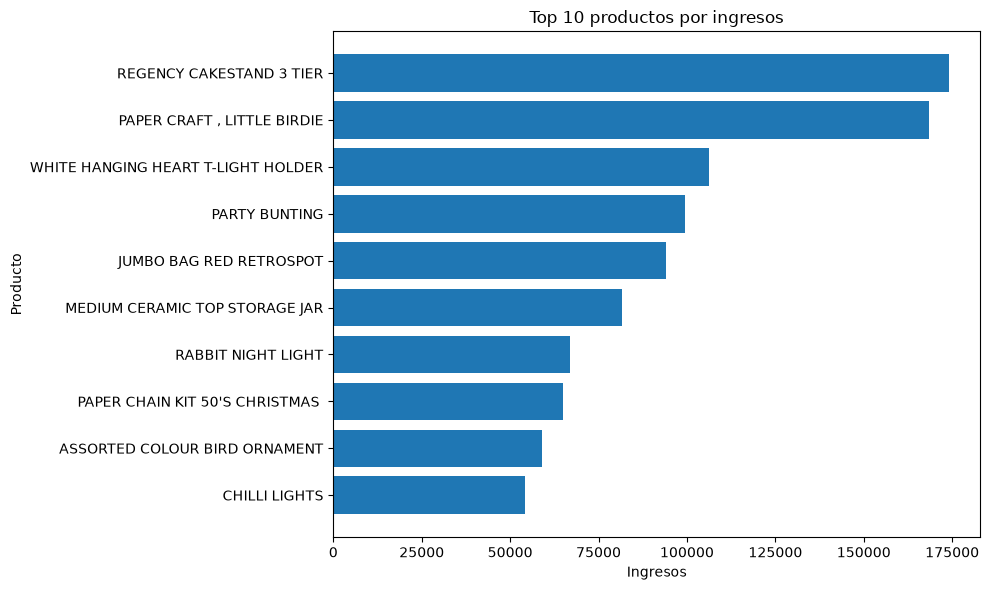

In [59]:
plt.figure(figsize=(10, 6))

plt.barh(top_productos.index, top_productos["Ingresos"])

plt.xlabel("Ingresos")
plt.ylabel("Producto")
plt.title("Top 10 productos por ingresos")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Análisis por países

Se analizaron los ingresos generados por cada país para identificar los mercados con mayor participación en las ventas.

In [61]:
ventas_pais = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
ventas_pais.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

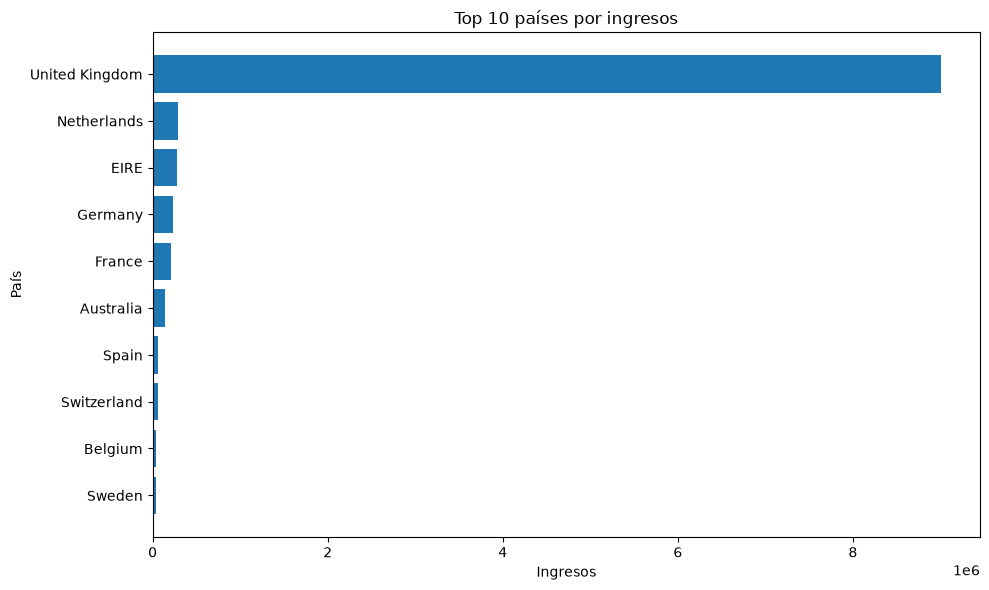

In [62]:
plt.figure(figsize=(10, 6))

plt.barh(ventas_pais.head(10).index, ventas_pais.head(10).values)

plt.xlabel("Ingresos")
plt.ylabel("País")
plt.title("Top 10 países por ingresos")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [63]:
uk_revenue = ventas_pais["United Kingdom"]

uk_porcentaje = (uk_revenue / df_clean["Revenue"].sum()) * 100

uk_porcentaje

np.float64(84.58607751590557)

## 10. Análisis de clientes

Se analizaron los clientes en función de sus ingresos generados, frecuencia de compra y ticket promedio, con el objetivo de identificar los clientes de mayor valor y comportamiento de compra.

In [64]:
df_clientes = df_clean.dropna(subset=["CustomerID"]).copy()
df_clientes["CustomerID"].nunique()

4339

In [65]:
ventas_cliente = (
    df_clientes.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
ventas_cliente.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [66]:
compras_cliente = (
    df_clientes.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)
compras_cliente.head(10)

CustomerID
12748.0    210
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     74
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [67]:
ticket_cliente = (
    df_clientes.groupby("CustomerID")
    .agg(
        Ingresos=("Revenue", "sum"),
        Compras=("InvoiceNo", "nunique")
    )
)

ticket_cliente["Ticket_Promedio"] = (
    ticket_cliente["Ingresos"] / ticket_cliente["Compras"]
)

ticket_cliente.sort_values(
    "Ticket_Promedio",
    ascending=False
).head(10)

,Ingresos,Compras,Ticket_Promedio
CustomerID,,,
16446.0,168472.50,2,84236.250000
12346.0,77183.60,1,77183.600000
15749.0,44534.30,3,14844.766667
15098.0,39916.50,3,13305.500000
12357.0,6207.67,1,6207.670000
12415.0,124914.53,21,5948.310952
12590.0,9864.26,2,4932.130000
12688.0,4873.81,1,4873.810000
12752.0,4366.78,1,4366.780000


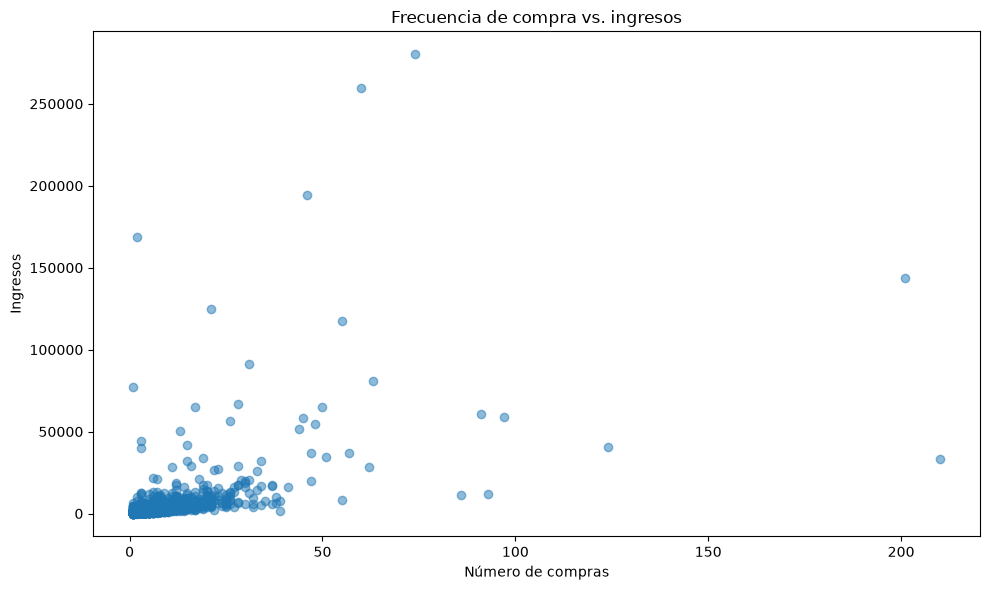

In [78]:
plt.figure(figsize=(10, 6))

plt.scatter(
    ticket_cliente["Compras"],
    ticket_cliente["Ingresos"],
    alpha=0.5
)

plt.xlabel("Número de compras")
plt.ylabel("Ingresos")
plt.title("Frecuencia de compra vs. ingresos")

plt.tight_layout()
plt.show()
# sns.scatterplot(data=ticket_cliente, x=ticket_cliente["Compras"], y=ticket_cliente["Ingresos"])

El análisis muestra que existe una relación imperfecta entre frecuencia de compra e ingresos. Algunos clientes generan altos ingresos con pocas compras, mientras que otros presentan una frecuencia elevada pero un valor económico menor por transacción.

## 11. Insights y conclusiones

### Principales insights

- **Alta concentración geográfica:** United Kingdom representa aproximadamente el 84,59 % de los ingresos, lo que evidencia una fuerte dependencia del mercado británico.

- **Estacionalidad de las ventas:** Noviembre de 2011 fue el mes con mayores ingresos, alcanzando aproximadamente 1,50 millones. Aunque diciembre presenta una facturación inferior, este resultado debe interpretarse con precaución debido a que el conjunto de datos solamente contiene información hasta el 9 de diciembre de 2011.

- **Productos de alto volumen:** PAPER CRAFT, LITTLE BIRDIE fue el producto con mayor cantidad de unidades vendidas, con 80.995 unidades.

- **Productos de mayor facturación:** REGENCY CAKESTAND 3 TIER generó los mayores ingresos entre los productos analizados, con 174.156,54.

- **Concentración de clientes:** algunos clientes generan una proporción importante de los ingresos. El cliente 14646 fue el de mayor facturación, con 280.206,02.

- **Frecuencia y valor no son lo mismo:** el cliente con mayor número de compras fue el 12748, con 210 facturas, mientras que el cliente 14646 lideró en ingresos. Esto demuestra que la frecuencia de compra y el valor generado deben analizarse como métricas diferentes.

### Conclusiones

El análisis permitió identificar patrones relevantes en el comportamiento de las ventas, los productos, los mercados y los clientes. Los resultados muestran una fuerte concentración de los ingresos en Reino Unido y en determinados clientes y productos.

El análisis temporal también permitió identificar variaciones importantes en los ingresos a lo largo del período estudiado, destacándose noviembre de 2011 como el mes de mayor facturación.

Finalmente, el análisis de clientes demuestra que la frecuencia de compra no necesariamente representa un mayor valor económico, por lo que resulta conveniente considerar conjuntamente métricas como ingresos, frecuencia y ticket promedio para evaluar el comportamiento de los clientes.

In [70]:
df_clean.shape

(525460, 10)

In [71]:
df_clean.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132728
Country             0
Revenue             0
YearMonth           0
dtype: int64

In [72]:
df_clean.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Revenue               float64
YearMonth           period[M]
dtype: object